### Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

### Create Cluster Data

In [2]:
X, y = make_blobs(n_samples=150, n_features=2, centers=3, 
           cluster_std=2.5, shuffle=True, random_state=42)

### Create linkages from the hierarchy

In [11]:
row_clusters = linkage(pdist(X, metric='euclidean'), method='complete')
# same as below don't need to use the pdist() - pairwise distance
row_clusters = linkage(X, metric='euclidean', method='complete')

### Review the linkages
- Each row represents one merge
- First and Second columns are the most disimilar points (since the method is 'complete')
- Third column represents the distance between those members ('euclidean')

In [12]:
pd.DataFrame(row_clusters,
             columns=['row label 1', 'row label 2',
                      'distance', 'no. of items in clust.'],
            index = ['cluster %d' % (i + 1) 
                     for i in range(row_clusters.shape[0])])

,row label 1,row label 2,distance,no. of items in clust.
cluster 1,24.0,52.0,0.030885,2.0
cluster 2,72.0,117.0,0.120936,2.0
cluster 3,74.0,124.0,0.142468,2.0
cluster 4,67.0,96.0,0.166616,2.0
cluster 5,7.0,108.0,0.167564,2.0
...,...,...,...,...
cluster 145,287.0,293.0,11.007042,48.0
cluster 146,289.0,292.0,12.186617,53.0
cluster 147,290.0,291.0,14.360744,49.0
cluster 148,294.0,295.0,21.326023,101.0


In [13]:
pd.DataFrame(linkage(X, metric='euclidean', method='complete'))

,0,1,2,3
0,24.0,52.0,0.030885,2.0
1,72.0,117.0,0.120936,2.0
2,74.0,124.0,0.142468,2.0
3,67.0,96.0,0.166616,2.0
4,7.0,108.0,0.167564,2.0
...,...,...,...,...
144,287.0,293.0,11.007042,48.0
145,289.0,292.0,12.186617,53.0
146,290.0,291.0,14.360744,49.0
147,294.0,295.0,21.326023,101.0


#### Generate the dendrogram chart

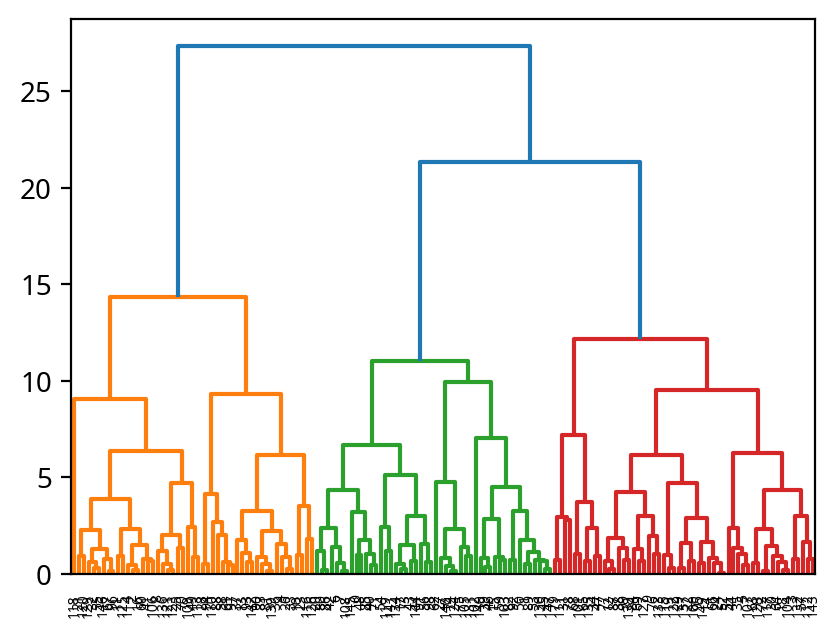

In [14]:
dendrogram(linkage(X, metric='euclidean', method='complete'));

#### Apply the AgglomerateClustering

In [18]:
from sklearn.cluster import AgglomerativeClustering

In [25]:
model = AgglomerativeClustering(n_clusters=3,
                               linkage='complete',
                               metric='euclidean')
y_pred = model.fit_predict(X)

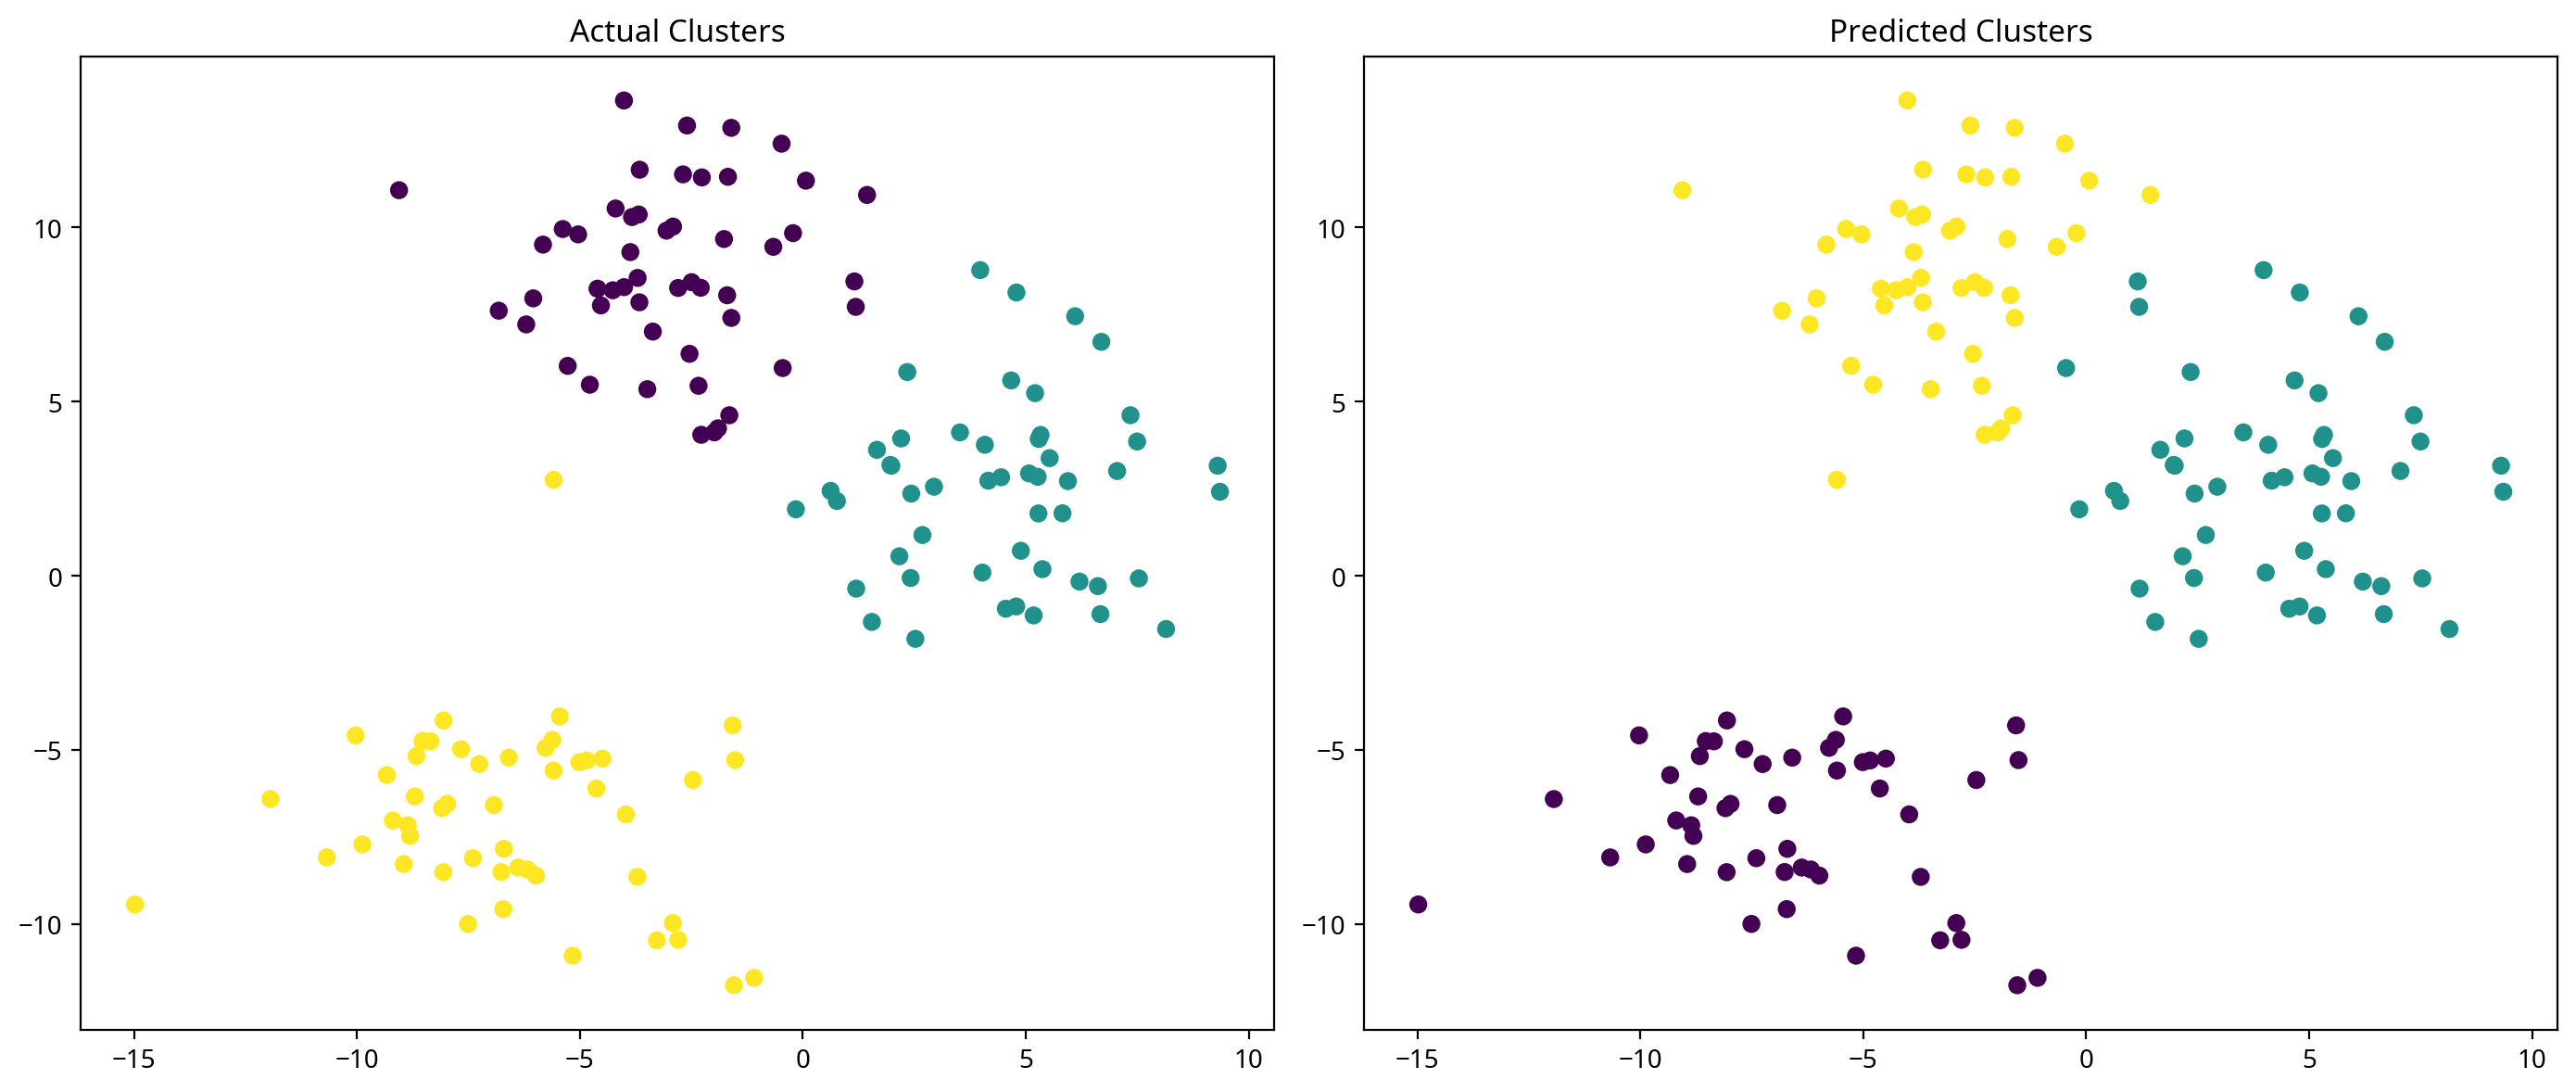

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].scatter(X[:,0], X[:,1], c=y)
axes[0].set_title('Actual Clusters')

axes[1].scatter(X[:,0], X[:,1], c=y_pred)
axes[1].set_title('Predicted Clusters')
plt.tight_layout()
plt.show()